# 🏠 EcoPredict v3 — Modélisation Multi-Départementale

**Objectif** : Prédire consommation énergétique, émissions CO₂ et coût annuel en intégrant les zones climatiques françaises.

**Départements** : 13, 33, 44, 59, 63, 67, 74, 75 — **Zones** : H1 (Froid), H2 (Tempéré), H3 (Méditerranéen)

**Stack** : Python 3.12 · XGBoost GPU · Optuna · Scikit-learn · Pandas

In [1]:
# ============================================================
# CELLULE 2 — Imports
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib seaborn optuna

import warnings
warnings.filterwarnings("ignore")

import glob, os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 80)
print("✅ Imports OK")

✅ Imports OK


In [2]:
# ============================================================
# CELLULE 3 — Chargement multi-départemental + zones climatiques
# ============================================================

DEPT_TO_ZONE = {
    "59": "H1",  # Nord — Continental
    "67": "H1",  # Bas-Rhin — Semi-continental
    "74": "H1",  # Haute-Savoie — Montagne
    "44": "H2",  # Loire-Atlantique — Océanique
    "33": "H2",  # Gironde — Océanique
    "75": "H2",  # Paris — Tempéré
    "63": "H2",  # Puy-de-Dôme — Tempéré
    "13": "H3",  # Bouches-du-Rhône — Méditerranéen
}

TARGETS = [
    "conso_3_usages_ep_m2_arrete_2012",
    "emission_ges_3_usages_ep_m2_arrete_2012",
]

FEATURES_NUM_RAW = [
    "surface_habitable_logement", "annee_construction_dpe",
    "nombre_niveau_logement", "nombre_niveau_immeuble",
    "surface_habitable_immeuble",
]

FEATURES_NUM_ENVELOPE = [
    "surface_mur_totale", "surface_mur_exterieur", "surface_mur_deperditif",
    "u_mur_exterieur", "surface_plancher_bas_totale",
    "surface_plancher_bas_deperditif", "surface_plancher_haut_totale",
    "surface_plancher_haut_deperditif", "u_baie_vitree",
    "facteur_solaire_baie_vitree",
]

FEATURES_NUM_VITRAGE = [
    "surface_vitree_nord", "surface_vitree_sud",
    "surface_vitree_ouest", "surface_vitree_est",
]

FEATURES_CAT_BASE = [
    "type_batiment_dpe", "type_energie_chauffage",
    "type_installation_chauffage", "type_generateur_chauffage",
    "type_energie_ecs", "type_generateur_ecs", "type_installation_ecs",
    "type_isolation_mur_exterieur", "type_isolation_plancher_bas",
    "type_isolation_plancher_haut", "materiaux_structure_mur_exterieur",
    "type_vitrage", "type_materiaux_menuiserie", "type_gaz_lame",
    "type_ventilation", "periode_construction_dpe",
    "chauffage_solaire", "ecs_solaire", "traversant",
    "presence_balcon", "classe_inertie",
]

LOAD_COLS = (FEATURES_NUM_RAW + FEATURES_NUM_ENVELOPE + FEATURES_NUM_VITRAGE
             + FEATURES_CAT_BASE + TARGETS + ["code_departement_insee"])

def load_all_dpe(folder="."):
    files = sorted(glob.glob(os.path.join(folder, "dpe_logement_*.csv")))
    frames = []
    for f in files:
        dept = os.path.basename(f).replace("dpe_logement_", "").replace(".csv", "")
        print(f"  📂 {os.path.basename(f)} (dept {dept})...", end=" ")
        chunk = pd.read_csv(f, sep=";", usecols=LOAD_COLS, low_memory=False)
        chunk["code_departement"] = dept
        chunk["zone_climatique"] = DEPT_TO_ZONE.get(dept, "inconnu")
        print(f"{len(chunk):,} lignes")
        frames.append(chunk)
    return pd.concat(frames, ignore_index=True)

print("🔄 Chargement des fichiers DPE multi-départements...")
df_raw = load_all_dpe(".")
print(f"\n✅ Dataset brut : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"   Départements : {sorted(df_raw['code_departement'].unique())}")
print(f"   Zones        : {sorted(df_raw['zone_climatique'].unique())}")
print(f"\n📊 Répartition par zone et département :")
print(df_raw.groupby(["zone_climatique", "code_departement"]).size().to_string())

🔄 Chargement des fichiers DPE multi-départements...
  📂 dpe_logement_13.csv (dept 13)... 425,997 lignes
  📂 dpe_logement_33.csv (dept 33)... 419,862 lignes
  📂 dpe_logement_44.csv (dept 44)... 445,540 lignes
  📂 dpe_logement_59.csv (dept 59)... 638,635 lignes
  📂 dpe_logement_63.csv (dept 63)... 154,745 lignes
  📂 dpe_logement_67.csv (dept 67)... 317,792 lignes
  📂 dpe_logement_74.csv (dept 74)... 232,296 lignes
  📂 dpe_logement_75.csv (dept 75)... 914,263 lignes

✅ Dataset brut : 3,549,130 lignes × 45 colonnes
   Départements : ['13', '33', '44', '59', '63', '67', '74', '75']
   Zones        : ['H1', 'H2', 'H3']

📊 Répartition par zone et département :
zone_climatique  code_departement
H1               59                  638635
                 67                  317792
                 74                  232296
H2               33                  419862
                 44                  445540
                 63                  154745
                 75                  914

In [3]:
# ============================================================
# CELLULE 4 — Sélection des features
# ============================================================

FEATURES_NUM_ALL = FEATURES_NUM_RAW + FEATURES_NUM_ENVELOPE + FEATURES_NUM_VITRAGE
FEATURES_CAT = FEATURES_CAT_BASE + ["zone_climatique", "code_departement"]

COLS = FEATURES_NUM_ALL + FEATURES_CAT + TARGETS
df = df_raw[COLS].copy()

print(f"✅ Colonnes retenues : {len(COLS)}")
print(f"   → {len(FEATURES_NUM_ALL)} numériques + {len(FEATURES_CAT)} catégorielles + {len(TARGETS)} cibles")

✅ Colonnes retenues : 44
   → 19 numériques + 23 catégorielles + 2 cibles


In [4]:
# ============================================================
# CELLULE 5 — Nettoyage + IQR + Feature Engineering
# ============================================================

# --- Valeurs manquantes ---
df.dropna(subset=TARGETS, inplace=True)
print(f"Après suppression lignes sans cible : {len(df):,}")

for col in FEATURES_NUM_ALL:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in FEATURES_CAT:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("inconnu")

# Cast str uniforme (évite TypeError OrdinalEncoder)
for col in FEATURES_CAT:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": "inconnu", "NaN": "inconnu", "None": "inconnu", "": "inconnu"})

# --- Filtrage physique ---
n_before = len(df)
df = df[df["surface_habitable_logement"].between(9, 500)]
df = df[df["annee_construction_dpe"].between(1800, 2025)]
df = df[df["conso_3_usages_ep_m2_arrete_2012"] > 0]
df = df[df["emission_ges_3_usages_ep_m2_arrete_2012"] >= 0]
print(f"Après filtrage physique : {len(df):,} (−{n_before - len(df):,})")

# --- IQR outlier removal ---
def remove_outliers_iqr(dataframe, column, k=1.5):
    Q1, Q3 = dataframe[column].quantile(0.25), dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    mask = dataframe[column].between(Q1 - k * IQR, Q3 + k * IQR)
    removed = (~mask).sum()
    print(f"  IQR {column}: [{Q1 - k*IQR:.1f}, {Q3 + k*IQR:.1f}] → −{removed:,}")
    return dataframe[mask]

df = remove_outliers_iqr(df, "conso_3_usages_ep_m2_arrete_2012", k=1.5)
df = remove_outliers_iqr(df, "emission_ges_3_usages_ep_m2_arrete_2012", k=1.5)
df = remove_outliers_iqr(df, "surface_habitable_logement", k=2.0)

# --- Cohérence thermique ---
n_before = len(df)
mask_bad = ((df["annee_construction_dpe"] >= 2013) & (df["conso_3_usages_ep_m2_arrete_2012"] > 250))
mask_old = ((df["annee_construction_dpe"] < 1950) & (df["conso_3_usages_ep_m2_arrete_2012"] < 50))
df = df[~mask_bad & ~mask_old]
print(f"Cohérence thermique : −{n_before - len(df):,}")

# --- Feature Engineering ---
df["is_rt2012"] = (df["annee_construction_dpe"] >= 2013).astype(int)
df["age_batiment"] = 2026 - df["annee_construction_dpe"]
df["surface_vitree_totale"] = (df["surface_vitree_nord"] + df["surface_vitree_sud"]
                               + df["surface_vitree_ouest"] + df["surface_vitree_est"])
df["ratio_vitrage"] = (df["surface_vitree_totale"] / df["surface_habitable_logement"].clip(lower=1)).round(4)
df["ratio_mur_deperditif"] = (df["surface_mur_deperditif"] / df["surface_mur_totale"].clip(lower=1)).clip(0, 1).round(4)
df["surface_par_niveau"] = (df["surface_habitable_logement"] / df["nombre_niveau_logement"].clip(lower=1)).round(2)
df["compacite"] = (df["surface_mur_exterieur"] / df["surface_habitable_logement"].clip(lower=1)).round(4)

FEATURES_ENGINEERED = [
    "is_rt2012", "age_batiment", "surface_vitree_totale",
    "ratio_vitrage", "ratio_mur_deperditif", "surface_par_niveau", "compacite",
]
FEATURES_NUM = FEATURES_NUM_ALL + FEATURES_ENGINEERED

# --- Coût annuel (tarifs réels 2025) ---
TARIFS_ENERGIE = {
    "electricite": 0.2516, "gaz": 0.1284, "fioul": 0.119,
    "bois": 0.07, "charbon": 0.09, "gpl": 0.155, "reseau": 0.105,
}
TARIF_DEFAULT = 0.15

def get_tarif(e):
    if pd.isna(e) or str(e).lower() in ("nan", "inconnu", ""):
        return TARIF_DEFAULT
    e_low = str(e).lower().strip()
    for key, t in TARIFS_ENERGIE.items():
        if key in e_low:
            return t
    return TARIF_DEFAULT

def coef_ep_ef(e):
    if pd.isna(e):
        return 1.0
    return 1 / 2.3 if "electri" in str(e).lower() else 1.0

df["cout_annuel_estim"] = (
    df["conso_3_usages_ep_m2_arrete_2012"]
    * df["type_energie_chauffage"].apply(coef_ep_ef)
    * df["surface_habitable_logement"]
    * df["type_energie_chauffage"].apply(get_tarif)
).round(2)

print(f"\n✅ Dataset final : {len(df):,} lignes")
print(f"   Features : {len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat = {len(FEATURES_NUM) + len(FEATURES_CAT)}")
print(f"\n📊 Répartition par zone après nettoyage :")
print(df["zone_climatique"].value_counts().sort_index())

Après suppression lignes sans cible : 1,253,672
Après filtrage physique : 1,012,261 (−241,411)
  IQR conso_3_usages_ep_m2_arrete_2012: [-93.6, 478.5] → −24,048
  IQR emission_ges_3_usages_ep_m2_arrete_2012: [-33.8, 83.0] → −24,026
  IQR surface_habitable_logement: [-45.0, 190.0] → −23,450
Cohérence thermique : −3,257

✅ Dataset final : 937,480 lignes
   Features : 26 num + 23 cat = 49

📊 Répartition par zone après nettoyage :
zone_climatique
H1    346149
H2    466346
H3    124985
Name: count, dtype: int64


---
## Analyse Exploratoire par Zone Climatique

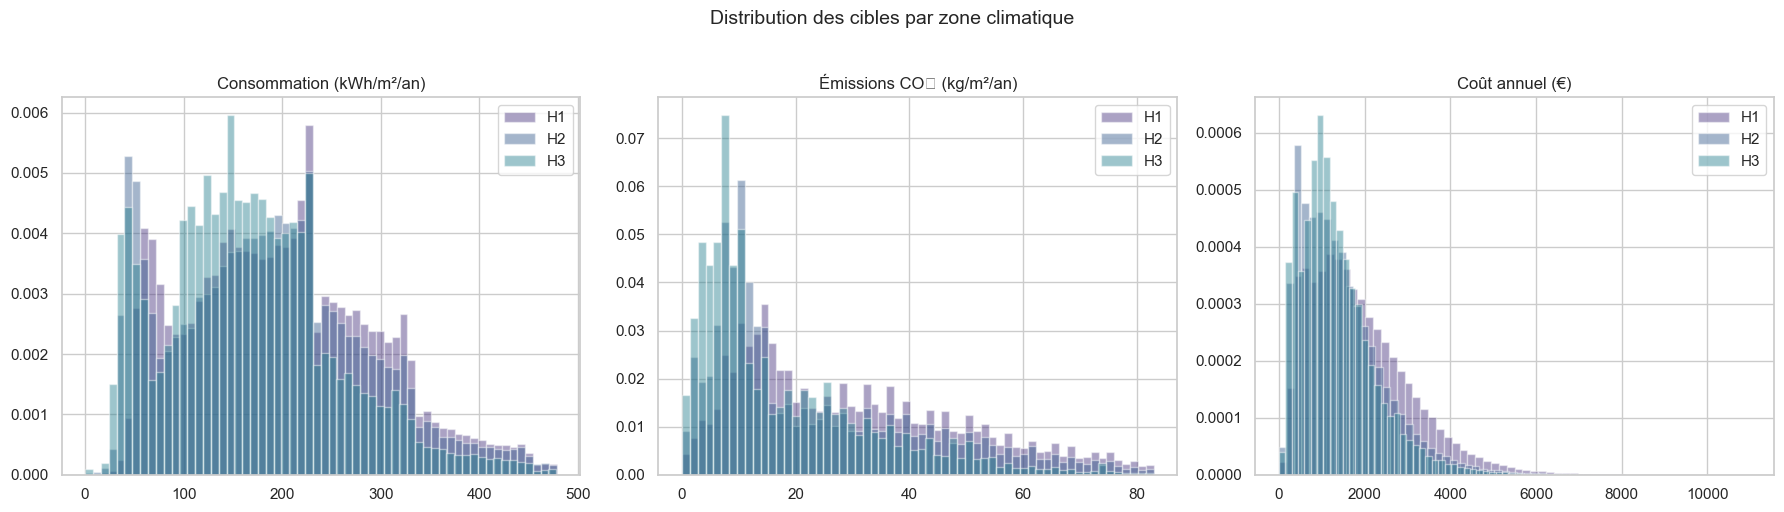

In [5]:
# ============================================================
# CELLULE 7 — Distribution des cibles par zone climatique
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
targets_info = [
    ("conso_3_usages_ep_m2_arrete_2012", "Consommation (kWh/m²/an)", "#2ecc71"),
    ("emission_ges_3_usages_ep_m2_arrete_2012", "Émissions CO₂ (kg/m²/an)", "#3498db"),
    ("cout_annuel_estim", "Coût annuel (€)", "#e67e22"),
]

for ax, (col, title, _) in zip(axes, targets_info):
    for zone in ["H1", "H2", "H3"]:
        subset = df[df["zone_climatique"] == zone][col]
        ax.hist(subset, bins=60, alpha=0.45, label=zone, density=True)
    ax.set_title(title, fontsize=12)
    ax.legend()

plt.suptitle("Distribution des cibles par zone climatique", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

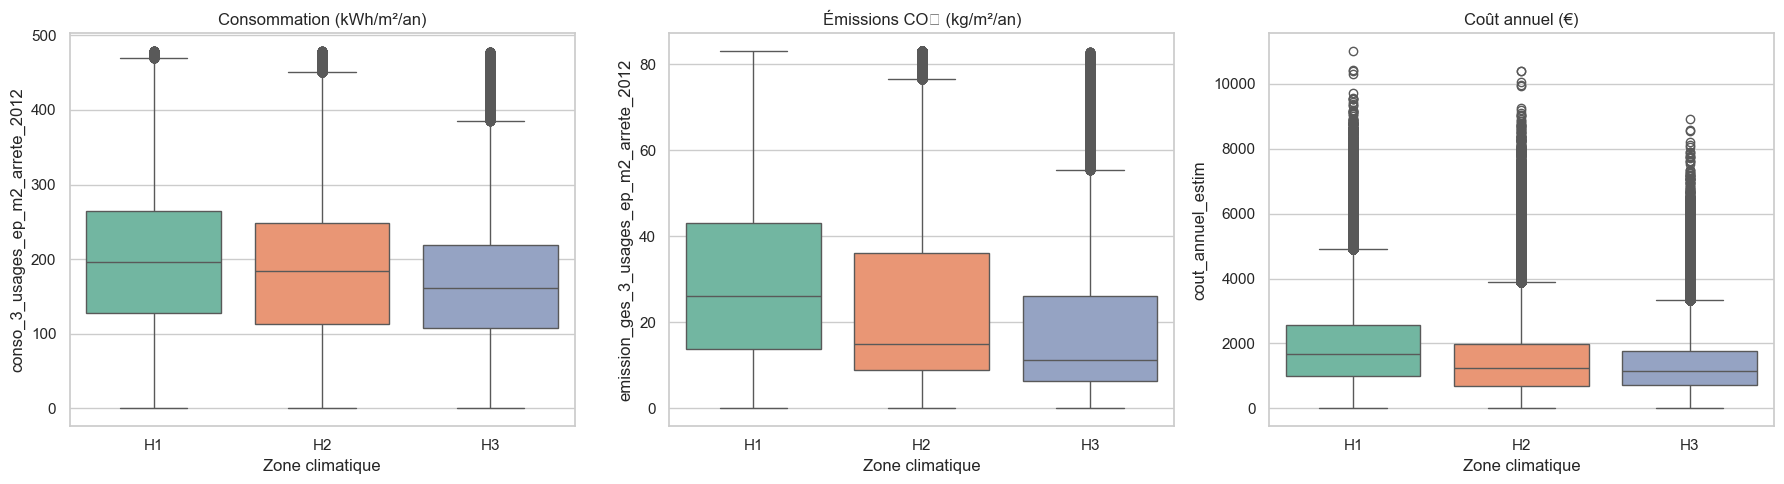

📊 Moyennes par zone climatique :


,conso_3_usages_ep_m2_arrete_2012,emission_ges_3_usages_ep_m2_arrete_2012,cout_annuel_estim
zone_climatique,,,
H1,200.74,29.96,1890.21
H2,186.98,23.57,1458.93
H3,168.44,17.89,1347.75


In [6]:
# ============================================================
# CELLULE 8 — Boxplots par zone + Statistiques
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, _) in zip(axes, targets_info):
    sns.boxplot(data=df, x="zone_climatique", y=col, ax=ax,
                palette="Set2", order=["H1", "H2", "H3"])
    ax.set_title(title)
    ax.set_xlabel("Zone climatique")

plt.tight_layout()
plt.show()

print("📊 Moyennes par zone climatique :")
display(df.groupby("zone_climatique")[TARGETS + ["cout_annuel_estim"]].mean().round(2))

---
## Modélisation — XGBoost MultiOutput GPU

In [7]:
# ============================================================
# CELLULE 10 — Préparation X/y + Train/Test split stratifié
# ============================================================

ALL_FEATURES = FEATURES_NUM + FEATURES_CAT
X = df[ALL_FEATURES].copy()
y = df[TARGETS + ["cout_annuel_estim"]].copy()

TARGET_NAMES = [
    "Consommation (kWh/m²/an)",
    "Émissions CO₂ (kg/m²/an)",
    "Coût annuel (€)",
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df.loc[X.index, "zone_climatique"],
)

print(f"Features : {X.shape[1]} ({len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat)")
print(f"Train    : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")
print(f"\nDistribution zones (test) :")
print(X_test["zone_climatique"].value_counts().sort_index())

Features : 49 (26 num + 23 cat)
Train    : 749,984 | Test : 187,496

Distribution zones (test) :
zone_climatique
H1    69230
H2    93269
H3    24997
Name: count, dtype: int64


In [8]:
# ============================================================
# CELLULE 11 — Optuna + Pipeline (subsample 500k pour la vitesse)
# ============================================================

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), FEATURES_CAT),
])

# Subsample pour Optuna (garde la rapidité GPU)
MAX_OPTUNA_ROWS = 500_000
if len(X_train) > MAX_OPTUNA_ROWS:
    idx = X_train.sample(MAX_OPTUNA_ROWS, random_state=42).index
    X_opt, y_opt = X_train.loc[idx], y_train.loc[idx]
    print(f"⚡ Optuna subsample : {len(X_opt):,} / {len(X_train):,}")
else:
    X_opt, y_opt = X_train, y_train

def optuna_objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":       trial.suggest_int("max_depth", 4, 10),
        "learning_rate":   trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "subsample":       trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 0.95),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "min_child_weight":trial.suggest_int("min_child_weight", 1, 15),
    }
    xgb = XGBRegressor(
        **params, tree_method="hist", device="cuda",
        sampling_method="gradient_based", random_state=42, verbosity=0,
    )
    pipe = Pipeline([("preprocessor", preprocessor), ("model", xgb)])
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    return cross_val_score(
        pipe, X_opt, y_opt.iloc[:, 0], cv=kf, scoring="r2", n_jobs=1,
    ).mean()

N_TRIALS = 20
print(f"🔍 Optimisation Optuna ({N_TRIALS} trials, 3-Fold CV, GPU)...")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print(f"\n✅ Meilleur R² CV : {study.best_value:.4f}")
print("📋 Hyperparamètres optimaux :")
for k, v in best.items():
    print(f"   {k}: {v}")

⚡ Optuna subsample : 500,000 / 749,984
🔍 Optimisation Optuna (20 trials, 3-Fold CV, GPU)...


Best trial: 12. Best value: 0.773023: 100%|██████████| 20/20 [09:04<00:00, 27.23s/it]


✅ Meilleur R² CV : 0.7730
📋 Hyperparamètres optimaux :
   n_estimators: 500
   max_depth: 10
   learning_rate: 0.06503408622669836
   subsample: 0.6012742608578389
   colsample_bytree: 0.520270776980314
   reg_alpha: 0.054888893835200646
   reg_lambda: 0.001342039182008899
   min_child_weight: 11


In [9]:
# ============================================================
# CELLULE 12 — Entraînement final MultiOutput (tous les données)
# ============================================================

xgb_best = XGBRegressor(
    **best, tree_method="hist", device="cuda",
    sampling_method="gradient_based", random_state=42, verbosity=0,
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MultiOutputRegressor(xgb_best, n_jobs=1)),
])

pipeline.fit(X_train, y_train)
print(f"✅ Modèle final entraîné sur {len(X_train):,} lignes")

✅ Modèle final entraîné sur 749,984 lignes


---
## Évaluation & Analyse Géographique

In [10]:
# ============================================================
# CELLULE 14 — Métriques globales
# ============================================================

y_pred = pipeline.predict(X_test)

print("=" * 60)
print("📈 MÉTRIQUES GLOBALES (test set)")
print("=" * 60)

metrics_rows = []
for i, name in enumerate(TARGET_NAMES):
    r2  = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    metrics_rows.append({"Cible": name, "R²": round(r2, 4), "MAE": round(mae, 2), "RMSE": round(rmse, 2)})
    print(f"\n🎯 {name}")
    print(f"   R² = {r2:.4f}  |  MAE = {mae:.2f}  |  RMSE = {rmse:.2f}")

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

📈 MÉTRIQUES GLOBALES (test set)

🎯 Consommation (kWh/m²/an)
   R² = 0.7783  |  MAE = 29.68  |  RMSE = 44.90

🎯 Émissions CO₂ (kg/m²/an)
   R² = 0.8406  |  MAE = 4.63  |  RMSE = 7.70

🎯 Coût annuel (€)
   R² = 0.8528  |  MAE = 255.00  |  RMSE = 415.88


,Cible,R²,MAE,RMSE
0,Consommation (kWh/m²/an),0.7783,29.68,44.90
1,Émissions CO₂ (kg/m²/an),0.8406,4.63,7.70
2,Coût annuel (€),0.8528,255.00,415.88


In [11]:
# ============================================================
# CELLULE 15 — Rapport d'erreur par zone climatique & département
# ============================================================

print("=" * 60)
print("🌍 MÉTRIQUES PAR ZONE CLIMATIQUE")
print("=" * 60)

zone_test = X_test["zone_climatique"].values
zone_report = []

for zone in ["H1", "H2", "H3"]:
    mask = zone_test == zone
    if mask.sum() == 0:
        continue
    row = {"Zone": zone, "N": int(mask.sum())}
    for i, name in enumerate(TARGET_NAMES):
        r2 = r2_score(y_test.iloc[mask, i], y_pred[mask, i])
        mae = mean_absolute_error(y_test.iloc[mask, i], y_pred[mask, i])
        short = name.split("(")[0].strip()
        row[f"R² {short}"] = round(r2, 4)
        row[f"MAE {short}"] = round(mae, 2)
    zone_report.append(row)

zone_df = pd.DataFrame(zone_report)
display(zone_df)

# Détail par département
print("\n📊 Détail par département (Consommation) :")
dept_test = X_test["code_departement"].values
for dept in sorted(set(dept_test)):
    mask = dept_test == dept
    zone = DEPT_TO_ZONE.get(dept, "?")
    r2 = r2_score(y_test.iloc[mask, 0], y_pred[mask, 0])
    mae = mean_absolute_error(y_test.iloc[mask, 0], y_pred[mask, 0])
    print(f"  Dept {dept} ({zone}) : R²={r2:.4f}  MAE={mae:.2f} kWh/m²/an  (n={mask.sum():,})")

🌍 MÉTRIQUES PAR ZONE CLIMATIQUE


,Zone,N,R² Consommation,MAE Consommation,R² Émissions CO₂,MAE Émissions CO₂,R² Coût annuel,MAE Coût annuel
0,H1,69230,0.7962,28.91,0.828,5.12,0.8515,285.96
1,H2,93269,0.7626,30.97,0.834,4.56,0.8426,241.36
2,H3,24997,0.7659,27.00,0.846,3.50,0.8334,220.15



📊 Détail par département (Consommation) :
  Dept 13 (H3) : R²=0.7659  MAE=27.00 kWh/m²/an  (n=24,997)
  Dept 33 (H2) : R²=0.8247  MAE=22.16 kWh/m²/an  (n=25,598)
  Dept 44 (H2) : R²=0.8517  MAE=23.16 kWh/m²/an  (n=29,898)
  Dept 59 (H1) : R²=0.7825  MAE=28.13 kWh/m²/an  (n=35,799)
  Dept 63 (H2) : R²=0.7401  MAE=32.44 kWh/m²/an  (n=7,268)
  Dept 67 (H1) : R²=0.8083  MAE=27.93 kWh/m²/an  (n=21,048)
  Dept 74 (H1) : R²=0.7998  MAE=32.81 kWh/m²/an  (n=12,383)
  Dept 75 (H2) : R²=0.5671  MAE=45.67 kWh/m²/an  (n=30,505)


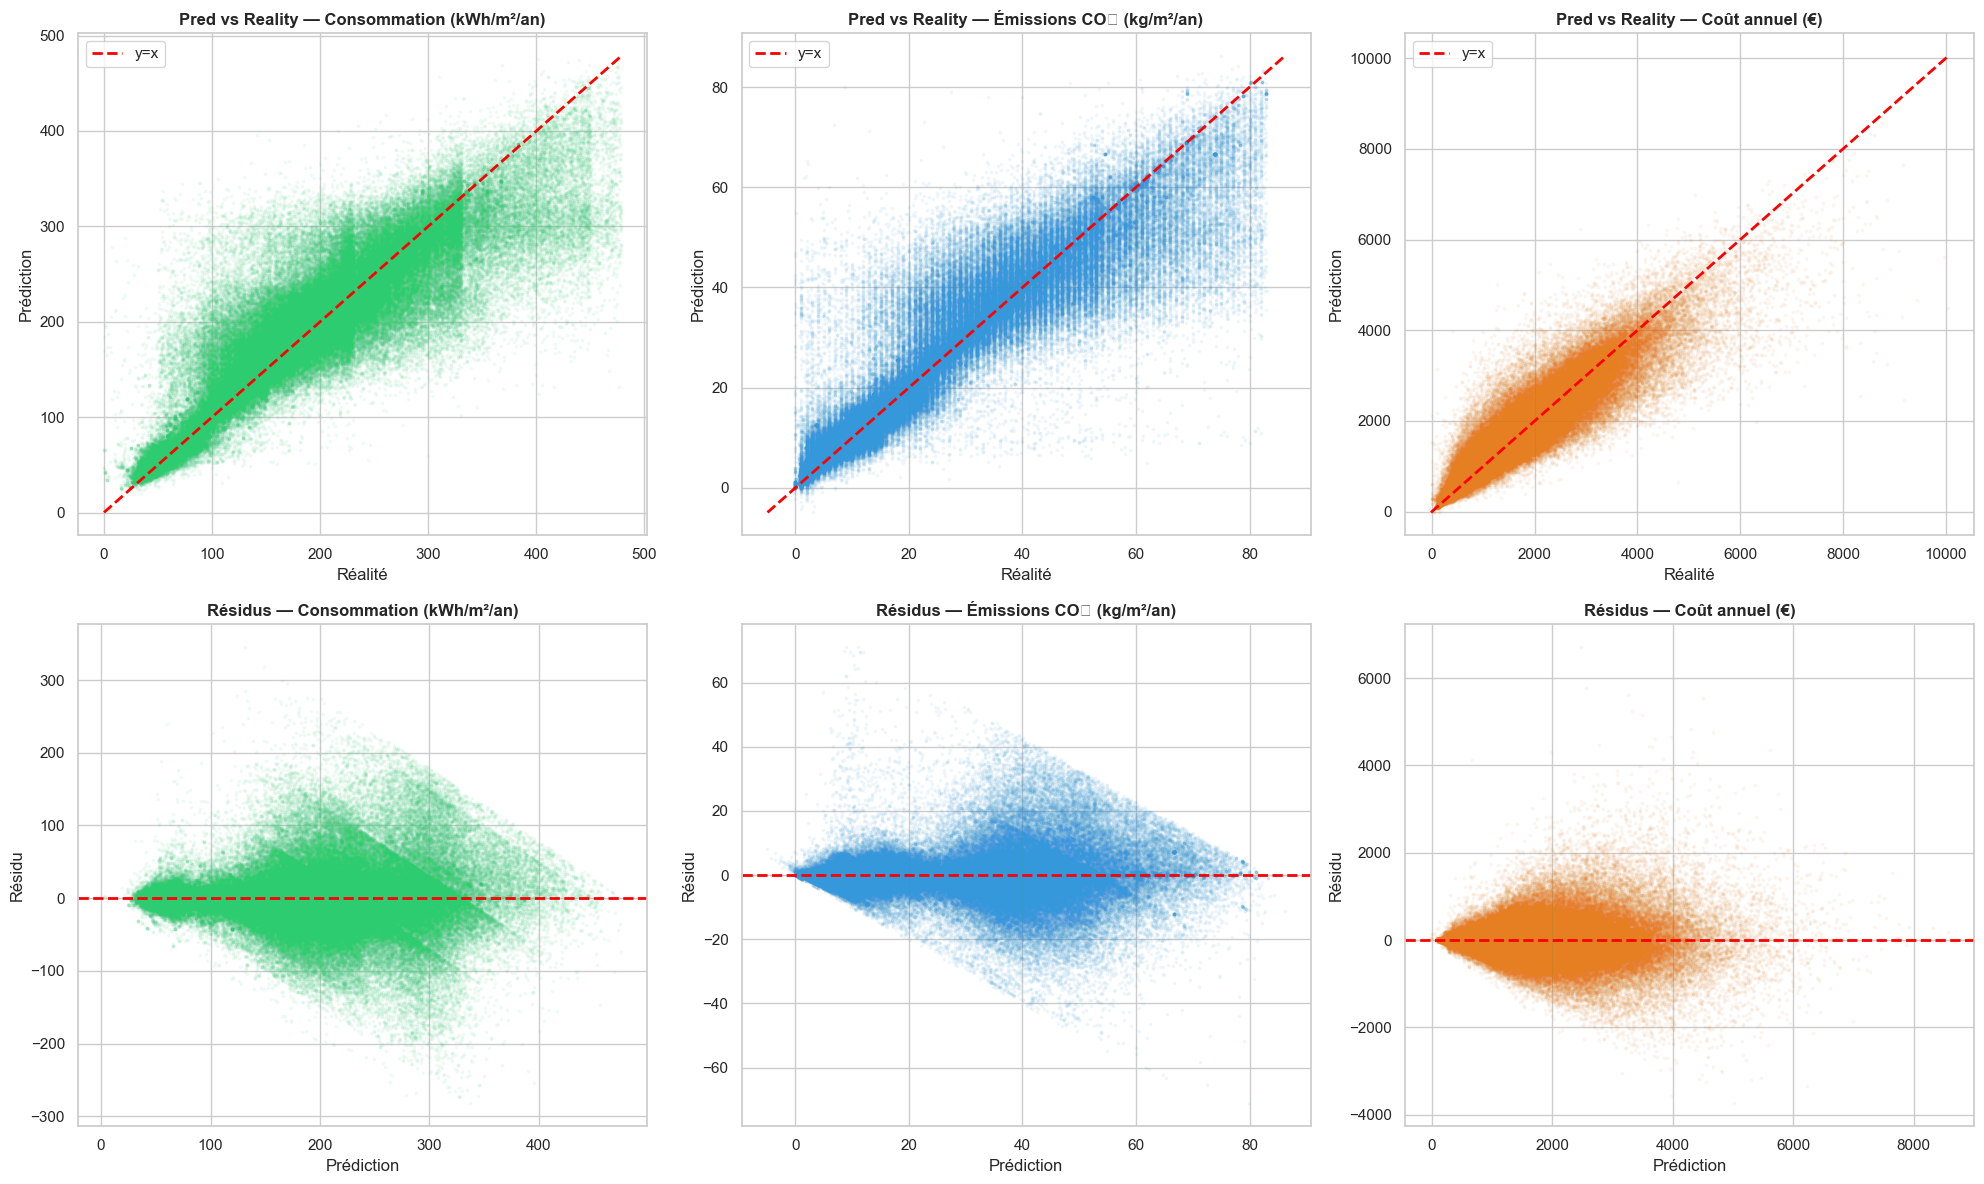

📊 Résidus Consommation : mean=0.02, std=44.90, median=-1.40


In [12]:
# ============================================================
# CELLULE 16 — Prédictions vs Réalité + Résidus
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = ["#2ecc71", "#3498db", "#e67e22"]

for i, (name, color) in enumerate(zip(TARGET_NAMES, colors)):
    y_true_i = y_test.iloc[:, i].values
    y_pred_i = y_pred[:, i]
    residuals = y_true_i - y_pred_i

    # Row 1: Pred vs Reality
    axes[0, i].scatter(y_true_i, y_pred_i, alpha=0.05, s=3, color=color)
    lims = [min(y_true_i.min(), y_pred_i.min()), max(y_true_i.max(), y_pred_i.max())]
    axes[0, i].plot(lims, lims, "r--", lw=2, label="y=x")
    axes[0, i].set_xlabel("Réalité")
    axes[0, i].set_ylabel("Prédiction")
    axes[0, i].set_title(f"Pred vs Reality — {name}", fontweight="bold")
    axes[0, i].legend()

    # Row 2: Residuals
    axes[1, i].scatter(y_pred_i, residuals, alpha=0.05, s=3, color=color)
    axes[1, i].axhline(0, color="red", ls="--", lw=2)
    axes[1, i].set_xlabel("Prédiction")
    axes[1, i].set_ylabel("Résidu")
    axes[1, i].set_title(f"Résidus — {name}", fontweight="bold")

plt.tight_layout()
plt.show()

# Résidus consommation
residuals_conso = y_test.iloc[:, 0].values - y_pred[:, 0]
print(f"📊 Résidus Consommation : mean={residuals_conso.mean():.2f}, "
      f"std={residuals_conso.std():.2f}, median={np.median(residuals_conso):.2f}")

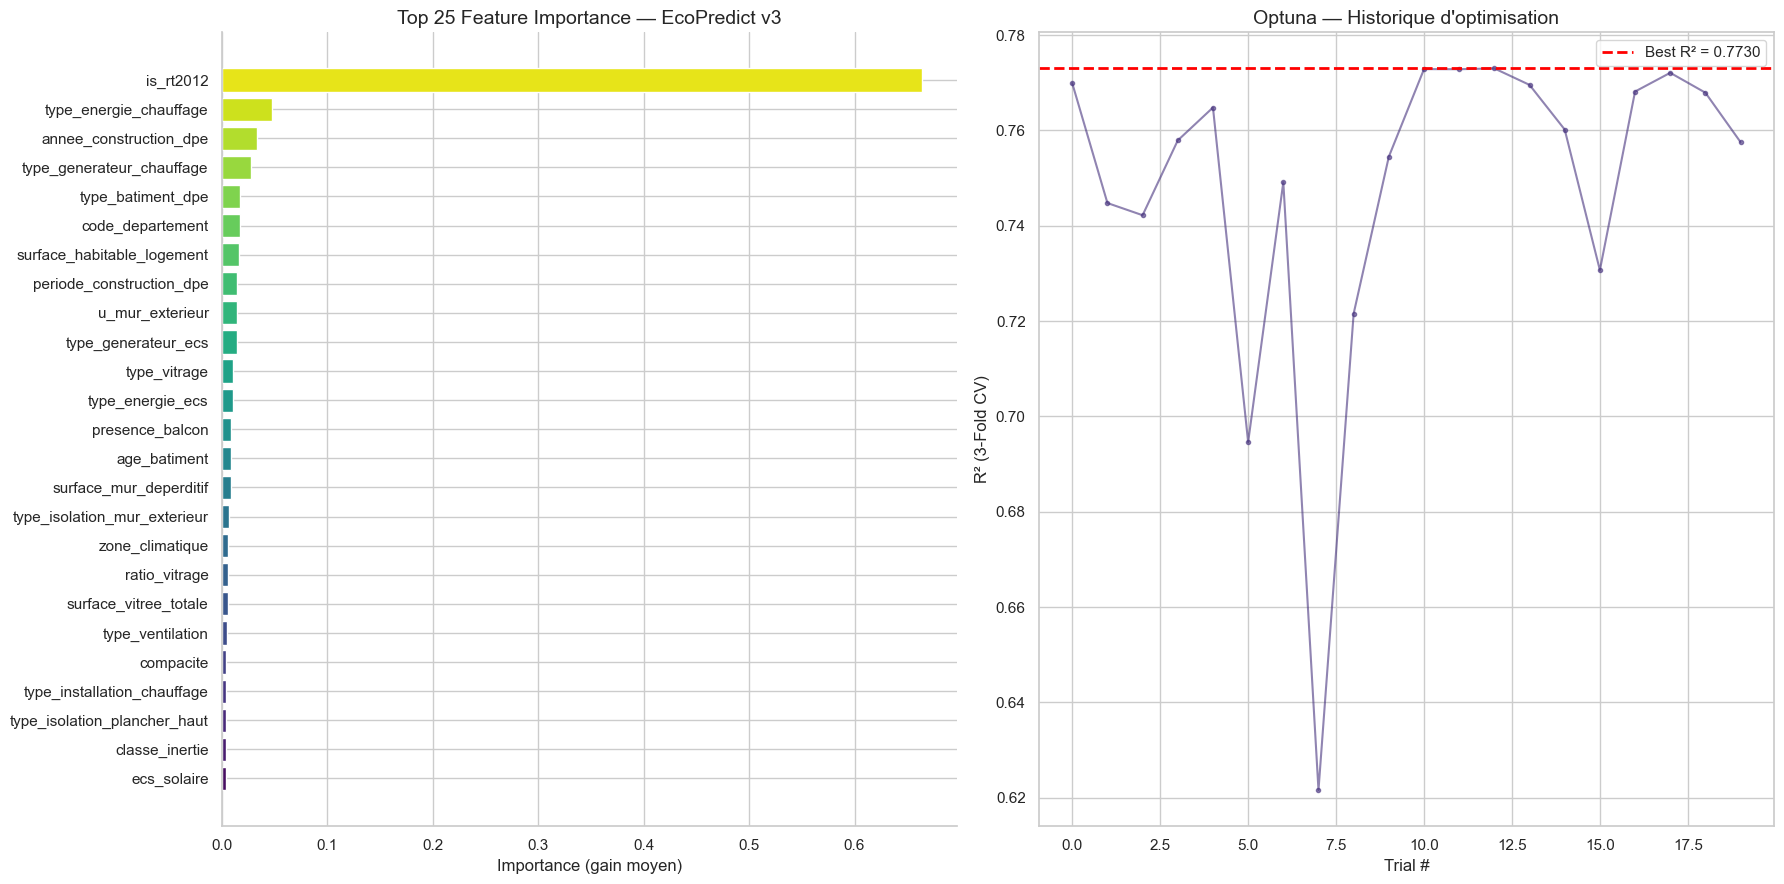


📊 Top 10 features :
  is_rt2012                                → 0.6641
  type_energie_chauffage                   → 0.0475
  annee_construction_dpe                   → 0.0333
  type_generateur_chauffage                → 0.0273
  type_batiment_dpe                        → 0.0172
  code_departement                         → 0.0167
  surface_habitable_logement               → 0.0160
  periode_construction_dpe                 → 0.0144
  u_mur_exterieur                          → 0.0141
  type_generateur_ecs                      → 0.0140


In [13]:
# ============================================================
# CELLULE 17 — Feature Importance + Optuna history
# ============================================================

feature_names = FEATURES_NUM + FEATURES_CAT
importances = np.mean(
    [est.feature_importances_ for est in pipeline.named_steps["model"].estimators_],
    axis=0,
)

fi_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=True)
    .tail(25)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].barh(fi_df["Feature"], fi_df["Importance"],
             color=sns.color_palette("viridis", len(fi_df)))
axes[0].set_xlabel("Importance (gain moyen)")
axes[0].set_title("Top 25 Feature Importance — EcoPredict v3", fontsize=14)
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

trials_df = study.trials_dataframe()
axes[1].plot(trials_df["number"], trials_df["value"], "o-", markersize=3, alpha=0.6)
axes[1].axhline(study.best_value, color="red", ls="--", lw=2,
                label=f"Best R² = {study.best_value:.4f}")
axes[1].set_xlabel("Trial #")
axes[1].set_ylabel("R² (3-Fold CV)")
axes[1].set_title("Optuna — Historique d'optimisation", fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Top 10 features :")
for _, row in fi_df.sort_values("Importance", ascending=False).head(10).iterrows():
    print(f"  {row['Feature']:40s} → {row['Importance']:.4f}")

---
## Interface de Simulation — `predict_energy()` v3

In [14]:
# ============================================================
# CELLULE 19 — Fonction de prédiction EcoPredict v3
# ============================================================

def predict_energy(
    surface: float,
    annee: int,
    zone_climatique: str = "H2",
    code_departement: str = "75",
    nb_niveaux: int = 1,
    nb_niveaux_immeuble: float = 0,
    surface_immeuble: float = 0,
    # Enveloppe thermique
    surface_mur_totale: float = 0,
    surface_mur_exterieur: float = 0,
    surface_mur_deperditif: float = 0,
    u_mur_exterieur: float = 0,
    surface_plancher_bas_totale: float = 0,
    surface_plancher_bas_deperditif: float = 0,
    surface_plancher_haut_totale: float = 0,
    surface_plancher_haut_deperditif: float = 0,
    u_baie_vitree: float = 0,
    facteur_solaire_baie_vitree: float = 0,
    # Vitrages
    surface_vitree_nord: float = 0,
    surface_vitree_sud: float = 0,
    surface_vitree_ouest: float = 0,
    surface_vitree_est: float = 0,
    # Catégorielles
    type_batiment: str = "maison",
    type_energie_chauffage: str = "gaz",
    type_installation_chauffage: str = "individuel",
    type_generateur_chauffage: str = "inconnu",
    type_energie_ecs: str = "inconnu",
    type_generateur_ecs: str = "inconnu",
    type_installation_ecs: str = "inconnu",
    type_isolation_mur: str = "ITI",
    type_isolation_plancher_bas: str = "inconnu",
    type_isolation_plancher_haut: str = "inconnu",
    materiaux_mur: str = "inconnu",
    type_vitrage: str = "double vitrage",
    type_menuiserie: str = "inconnu",
    type_gaz_lame: str = "inconnu",
    type_ventilation: str = "Ventilation mécanique auto réglable",
    periode_construction: str = "1975-1977",
    chauffage_solaire: str = "0",
    ecs_solaire: str = "0",
    traversant: str = "inconnu",
    presence_balcon: str = "inconnu",
    classe_inertie: str = "inconnu",
) -> dict:

    is_rt2012 = 1 if annee >= 2013 else 0
    age = 2026 - annee
    svt = surface_vitree_nord + surface_vitree_sud + surface_vitree_ouest + surface_vitree_est

    input_df = pd.DataFrame([{
        # Num raw
        "surface_habitable_logement": surface, "annee_construction_dpe": annee,
        "nombre_niveau_logement": nb_niveaux, "nombre_niveau_immeuble": nb_niveaux_immeuble,
        "surface_habitable_immeuble": surface_immeuble,
        # Enveloppe
        "surface_mur_totale": surface_mur_totale, "surface_mur_exterieur": surface_mur_exterieur,
        "surface_mur_deperditif": surface_mur_deperditif, "u_mur_exterieur": u_mur_exterieur,
        "surface_plancher_bas_totale": surface_plancher_bas_totale,
        "surface_plancher_bas_deperditif": surface_plancher_bas_deperditif,
        "surface_plancher_haut_totale": surface_plancher_haut_totale,
        "surface_plancher_haut_deperditif": surface_plancher_haut_deperditif,
        "u_baie_vitree": u_baie_vitree, "facteur_solaire_baie_vitree": facteur_solaire_baie_vitree,
        # Vitrage
        "surface_vitree_nord": surface_vitree_nord, "surface_vitree_sud": surface_vitree_sud,
        "surface_vitree_ouest": surface_vitree_ouest, "surface_vitree_est": surface_vitree_est,
        # Engineered
        "is_rt2012": is_rt2012, "age_batiment": age, "surface_vitree_totale": svt,
        "ratio_vitrage": round(svt / max(surface, 1), 4),
        "ratio_mur_deperditif": round(surface_mur_deperditif / max(surface_mur_totale, 1), 4) if surface_mur_totale > 0 else 0,
        "surface_par_niveau": round(surface / max(nb_niveaux, 1), 2),
        "compacite": round(surface_mur_exterieur / max(surface, 1), 4) if surface_mur_exterieur > 0 else 0,
        # Cat
        "type_batiment_dpe": type_batiment, "type_energie_chauffage": type_energie_chauffage,
        "type_installation_chauffage": type_installation_chauffage,
        "type_generateur_chauffage": type_generateur_chauffage,
        "type_energie_ecs": type_energie_ecs, "type_generateur_ecs": type_generateur_ecs,
        "type_installation_ecs": type_installation_ecs,
        "type_isolation_mur_exterieur": type_isolation_mur,
        "type_isolation_plancher_bas": type_isolation_plancher_bas,
        "type_isolation_plancher_haut": type_isolation_plancher_haut,
        "materiaux_structure_mur_exterieur": materiaux_mur,
        "type_vitrage": type_vitrage, "type_materiaux_menuiserie": type_menuiserie,
        "type_gaz_lame": type_gaz_lame, "type_ventilation": type_ventilation,
        "periode_construction_dpe": periode_construction,
        "chauffage_solaire": chauffage_solaire, "ecs_solaire": ecs_solaire,
        "traversant": traversant, "presence_balcon": presence_balcon,
        "classe_inertie": classe_inertie,
        "zone_climatique": zone_climatique, "code_departement": code_departement,
    }])

    pred = pipeline.predict(input_df)[0]
    conso = round(float(pred[0]), 1)
    co2 = round(float(pred[1]), 1)

    tarif = get_tarif(type_energie_chauffage)
    coef = coef_ep_ef(type_energie_chauffage)
    cout_reel = round(float(pred[0]) * coef * surface * tarif, 2)

    result = {
        "consommation_kwh_m2_an": conso,
        "emission_co2_kg_m2_an": co2,
        "cout_annuel_euros": cout_reel,
        "classe_energie": _classe_dpe(conso),
        "classe_ges": _classe_ges(co2),
        "zone_climatique": zone_climatique,
    }

    print("=" * 55)
    print("🏠 RÉSULTAT ECOPREDICT v3")
    print("=" * 55)
    print(f"  Surface        : {surface} m²")
    print(f"  Année          : {annee} ({'RT2012+' if is_rt2012 else 'pré-RT2012'})")
    print(f"  Zone           : {zone_climatique} (dept {code_departement})")
    print(f"  Bâtiment       : {type_batiment}")
    print(f"  Chauffage      : {type_energie_chauffage} ({type_installation_chauffage})")
    print(f"  Isolation murs : {type_isolation_mur}")
    print(f"  Tarif énergie  : {tarif} €/kWh ({type_energie_chauffage})")
    print("-" * 55)
    print(f"  📊 Consommation  : {conso:>8} kWh/m²/an")
    print(f"  🌿 Émissions CO₂ : {co2:>8} kg CO₂/m²/an")
    print(f"  💰 Coût annuel   : {cout_reel:>8} €/an")
    print(f"  🏷️  Classe DPE    : {result['classe_energie']}")
    print(f"  🏷️  Classe GES    : {result['classe_ges']}")
    print("=" * 55)
    return result


def _classe_dpe(c):
    if c <= 50: return "A"
    if c <= 90: return "B"
    if c <= 150: return "C"
    if c <= 230: return "D"
    if c <= 330: return "E"
    if c <= 450: return "F"
    return "G"


def _classe_ges(g):
    if g <= 5: return "A"
    if g <= 10: return "B"
    if g <= 20: return "C"
    if g <= 35: return "D"
    if g <= 55: return "E"
    if g <= 80: return "F"
    return "G"


print("✅ predict_energy() v3 prête (avec zone_climatique)")

✅ predict_energy() v3 prête (avec zone_climatique)


In [15]:
# ============================================================
# CELLULE 20 — Tests de simulation par zone
# ============================================================

# Test 1 : Lille (H1) — Appartement ancien, gaz collectif
print("🔹 TEST 1 — Lille (H1), appartement 1965, gaz collectif")
_ = predict_energy(
    65, 1965, zone_climatique="H1", code_departement="59",
    type_batiment="appartement", type_energie_chauffage="gaz",
    type_installation_chauffage="collectif",
    type_generateur_chauffage="chaudiere classique gaz",
    type_isolation_mur="non isole", type_vitrage="simple vitrage",
    periode_construction="1948-1974",
)

print()

# Test 2 : Bordeaux (H2) — Maison RT2012, PAC
print("🔹 TEST 2 — Bordeaux (H2), maison 2018, PAC électrique")
_ = predict_energy(
    120, 2018, zone_climatique="H2", code_departement="33",
    type_batiment="maison", type_energie_chauffage="electricite",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="pac air/eau",
    type_isolation_mur="ITE", type_vitrage="double vitrage",
    periode_construction="2013-2021",
)

print()

# Test 3 : Marseille (H3) — Appartement récent, PAC air/air
print("🔹 TEST 3 — Marseille (H3), appartement 2020, PAC air/air")
_ = predict_energy(
    55, 2020, zone_climatique="H3", code_departement="13",
    type_batiment="appartement", type_energie_chauffage="electricite",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="pac air/air",
    type_isolation_mur="ITE", type_vitrage="double vitrage",
    periode_construction="2013-2021",
)

print()

# Test 4 : Strasbourg (H1) — Maison fioul années 70
print("🔹 TEST 4 — Strasbourg (H1), maison 1975, fioul")
_ = predict_energy(
    95, 1975, zone_climatique="H1", code_departement="67",
    type_batiment="maison", type_energie_chauffage="fioul",
    type_installation_chauffage="individuel",
    type_generateur_chauffage="chaudiere classique fioul",
    type_isolation_mur="ITI", type_vitrage="double vitrage",
    periode_construction="1975-1977",
)

🔹 TEST 1 — Lille (H1), appartement 1965, gaz collectif
🏠 RÉSULTAT ECOPREDICT v3
  Surface        : 65 m²
  Année          : 1965 (pré-RT2012)
  Zone           : H1 (dept 59)
  Bâtiment       : appartement
  Chauffage      : gaz (collectif)
  Isolation murs : non isole
  Tarif énergie  : 0.1284 €/kWh (gaz)
-------------------------------------------------------
  📊 Consommation  :    133.9 kWh/m²/an
  🌿 Émissions CO₂ :     24.1 kg CO₂/m²/an
  💰 Coût annuel   :  1117.46 €/an
  🏷️  Classe DPE    : C
  🏷️  Classe GES    : D

🔹 TEST 2 — Bordeaux (H2), maison 2018, PAC électrique
🏠 RÉSULTAT ECOPREDICT v3
  Surface        : 120 m²
  Année          : 2018 (RT2012+)
  Zone           : H2 (dept 33)
  Bâtiment       : maison
  Chauffage      : electricite (individuel)
  Isolation murs : ITE
  Tarif énergie  : 0.2516 €/kWh (electricite)
-------------------------------------------------------
  📊 Consommation  :     46.0 kWh/m²/an
  🌿 Émissions CO₂ :      7.3 kg CO₂/m²/an
  💰 Coût annuel   :   603.

In [16]:
# ============================================================
# CELLULE 21 — Export du pipeline pour FastAPI
# ============================================================

MODEL_PATH = "ecopredict_v3_pipeline.joblib"
joblib.dump(pipeline, MODEL_PATH)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f"✅ Pipeline exporté : {MODEL_PATH} ({size_mb:.1f} MB)")
print(f"   Contient : preprocessor + MultiOutputRegressor(XGBRegressor)")
print(f"   Features : {len(ALL_FEATURES)} ({len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat)")
print(f"\n📦 Chargement futur (FastAPI) :")
print(f"   import joblib")
print(f"   pipeline = joblib.load('{MODEL_PATH}')")
print(f"   pipeline.predict(df_input)")

✅ Pipeline exporté : ecopredict_v3_pipeline.joblib (55.5 MB)
   Contient : preprocessor + MultiOutputRegressor(XGBRegressor)
   Features : 49 (26 num + 23 cat)

📦 Chargement futur (FastAPI) :
   import joblib
   pipeline = joblib.load('ecopredict_v3_pipeline.joblib')
   pipeline.predict(df_input)
